In [8]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print('Project root:', PROJECT_ROOT)
print('Figure directory:', FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [10]:
N = 300
d = 3

true_w = np.array([1.5, -2.0, 0.7])
true_b = 0.3
noise_std = 0.5

X_raw = np.random.randn(N, d)
epsilon = noise_std * np.random.randn(N)

y = X_raw @ true_w + true_b + epsilon

print("X_raw shape:", X_raw.shape)
print("true_w shape:", true_w.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X_raw:")
print(X_raw[:5])

print("\nFirst 5 y values:")
print(y[:5])

X_raw shape: (300, 3)
true_w shape: (3,)
epsilon shape: (300,)
y shape: (300,)

First 5 rows of X_raw:
[[ 1.76405235  0.40015721  0.97873798]
 [ 2.2408932   1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721 -0.10321885]
 [ 0.4105985   0.14404357  1.45427351]
 [ 0.76103773  0.12167502  0.44386323]]

First 5 y values:
[ 2.10001435 -1.09959058  2.13936629  1.74095784  1.08304622]


In [12]:
ones = np.ones(N)

Phi = np.column_stack([X_raw, ones])

theta_true = np.concatenate([true_w, np.array([true_b])])

print("ones shape:", ones.shape)
print("Phi shape:", Phi.shape)
print("theta_true shape:", theta_true.shape)

print("\nFirst 5 rows of Phi:")
print(Phi[:5])

print("\ntheta_true:")
print(theta_true)

ones shape: (300,)
Phi shape: (300, 4)
theta_true shape: (4,)

First 5 rows of Phi:
[[ 1.76405235  0.40015721  0.97873798  1.        ]
 [ 2.2408932   1.86755799 -0.97727788  1.        ]
 [ 0.95008842 -0.15135721 -0.10321885  1.        ]
 [ 0.4105985   0.14404357  1.45427351  1.        ]
 [ 0.76103773  0.12167502  0.44386323  1.        ]]

theta_true:
[ 1.5 -2.   0.7  0.3]


In [16]:
indices = np.random.permutation(N)


n_train = int(0.6 * N)
n_val = int(0.2*N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

Phi_train = Phi[train_idx]
y_train = y[train_idx]

Phi_val = Phi[val_idx]
y_val = y[val_idx]

Phi_test = Phi[test_idx]
y_test = y[test_idx]

print("Phi_train shape:", Phi_train.shape)
print("y_train shape:", y_train.shape)

print("Phi_val shape:", Phi_val.shape)
print("y_val shape:", y_val.shape)

print("Phi_test shape:", Phi_test.shape)
print("y_test shape:", y_test.shape)

Phi_train shape: (180, 4)
y_train shape: (180,)
Phi_val shape: (60, 4)
y_val shape: (60,)
Phi_test shape: (60, 4)
y_test shape: (60,)


In [18]:
theta_hat, residuals, rank, singular_values = np.linalg.lstsq(Phi_train,y_train, rcond=None)

print("theta_true:", theta_true)
print("theta_hat:", theta_hat)

print("\nEstimated weights:", theta_hat[:-1])
print("Estimated bias:", theta_hat[-1])

print("\nTrue weights:", true_w)
print("True bias:", true_b)

print("\nLeast-squares diagnostics:")
print("residuals:", residuals)
print("rank:", rank)
print("singular values:", singular_values)

theta_true: [ 1.5 -2.   0.7  0.3]
theta_hat: [ 1.51647634 -2.03100485  0.70686177  0.34566242]

Estimated weights: [ 1.51647634 -2.03100485  0.70686177]
Estimated bias: 0.34566242394357655

True weights: [ 1.5 -2.   0.7]
True bias: 0.3

Least-squares diagnostics:
residuals: [40.49161038]
rank: 4
singular values: [14.74479543 14.30380351 12.76654736 11.47644239]


In [20]:
def mse(y_true,y_pred):
    errors = y_pred - y_true
    return np.mean(errors**2)

y_pred_train = Phi_train @ theta_hat
y_pred_val = Phi_val @ theta_hat
y_pred_test = Phi_test @ theta_hat

train_mse = mse(y_train,y_pred_train)
val_mse = mse(y_val,y_pred_val)
test_mse = mse(y_test,y_pred_test)

print("Prediction shapes:")
print("y_pred_train shape:", y_pred_train.shape)
print("y_pred_val shape:", y_pred_val.shape)
print("y_pred_test shape:", y_pred_test.shape)

print("\nMSE values:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

Prediction shapes:
y_pred_train shape: (180,)
y_pred_val shape: (60,)
y_pred_test shape: (60,)

MSE values:
Train MSE: 0.224953390985401
Validation MSE: 0.22084706134065585
Test MSE: 0.18124651625032612


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp3_prediction_vs_truth.png


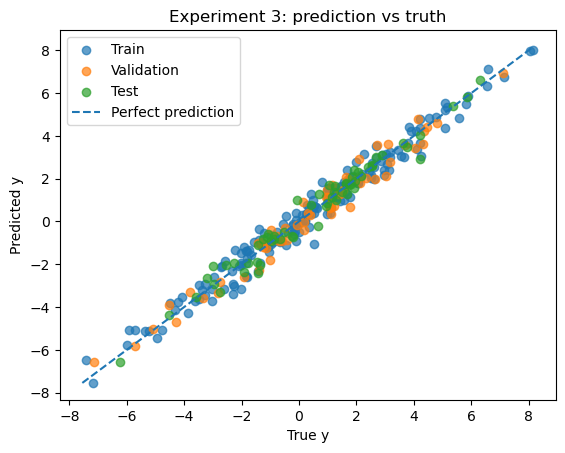

In [22]:
fig, ax = plt.subplots()

ax.scatter(y_train, y_pred_train, label="Train", alpha=0.7)
ax.scatter(y_val, y_pred_val, label="Validation", alpha=0.7)
ax.scatter(y_test, y_pred_test, label="Test", alpha=0.7)

min_value = min(y.min(), y_pred_train.min(), y_pred_val.min(), y_pred_test.min())
max_value = max(y.max(), y_pred_train.max(), y_pred_val.max(), y_pred_test.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title("Experiment 3: prediction vs truth")
ax.legend()

fig_path = FIGURE_DIR / "exp3_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp3_mse_comparison.png


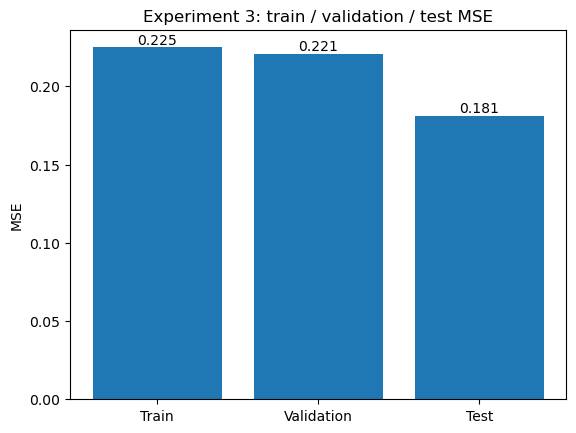

In [24]:
split_names = ["Train", "Validation", "Test"]
mse_values = [train_mse, val_mse, test_mse]

fig, ax = plt.subplots()

ax.bar(split_names, mse_values)
ax.set_ylabel("MSE")
ax.set_title("Experiment 3: train / validation / test MSE")

for i, value in enumerate(mse_values):
    ax.text(i, value, f"{value:.3f}", ha="center", va="bottom")

fig_path = FIGURE_DIR / "exp3_mse_comparison.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()